# We use KNN for: <br>
small dataset,<br>
zero values data,<br>
continuouse data,<br>
low scale of data,<br>
no relationship between independent columns.<br>

KNN = K = How may nearest neighbour we need.<br>

 Firstly it calculates the ditance of the points in dataset so for large datasets it takes time so we<br> dont use for large dataset and it cant predict the correct patterns.<br>

 small K = overfitting<br>
 large K = underfitting<br>

 Distance:<br>
 Eucledian,Manhhatton<br>
 Elbow methods are used to find the K value.<br>




# WHAT TECHNIQUE IS USED TO FILL MISSING VALUES MEAN OR MEDIAN <br>

->Firstly,we check the outliers.If it has outlier we use median <br>


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("knn_regression_dataset.csv")

In [4]:
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [5]:
df.isna().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [7]:
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


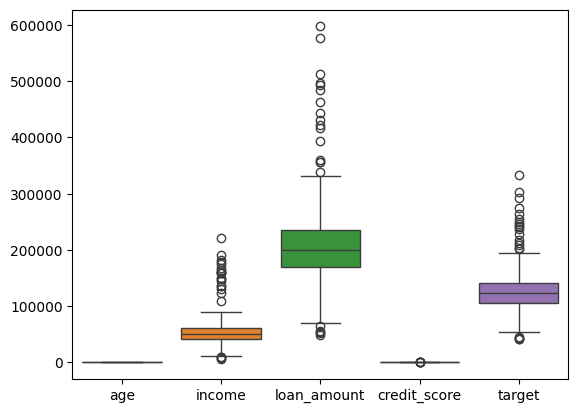

In [8]:
sns.boxplot(df)
plt.show()

<Axes: xlabel='income', ylabel='Count'>

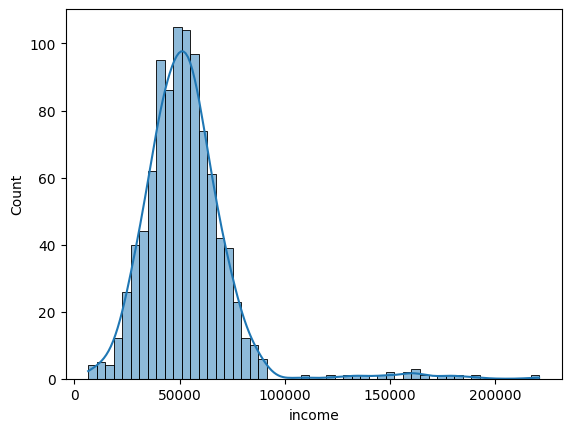

In [9]:
sns.histplot(df["income"],kde=True)

In [10]:
med=df["income"].median()
df["income"]=df["income"].fillna(med)
df["income"].isna().sum()

np.int64(0)

<Axes: xlabel='loan_amount', ylabel='Count'>

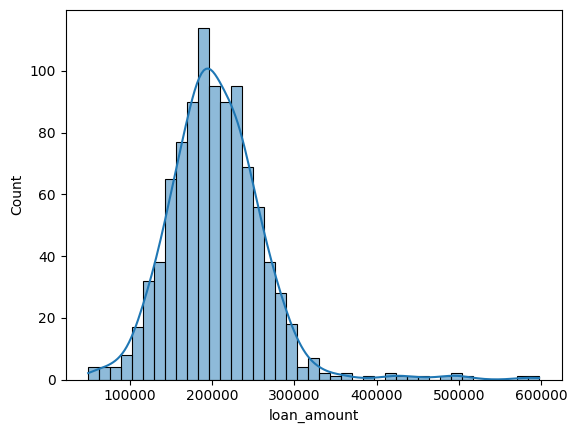

In [11]:
sns.histplot(df["loan_amount"],kde=True)

In [12]:
med=df["loan_amount"].median()
df["loan_amount"]=df["loan_amount"].fillna(med)
df["loan_amount"].isna().sum()


np.int64(0)

<Axes: xlabel='credit_score', ylabel='Count'>

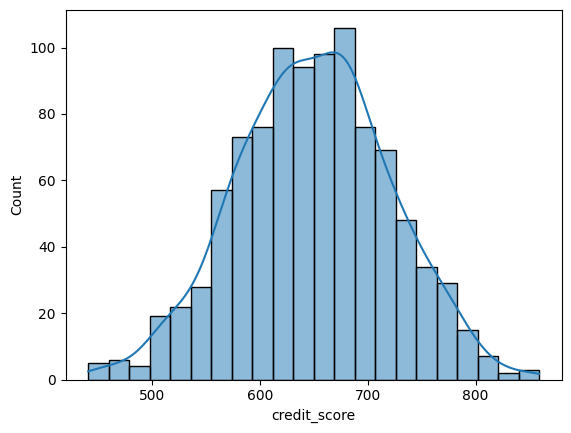

In [13]:
sns.histplot(df["credit_score"],kde=True)

In [14]:
med=df["credit_score"].median()
df["credit_score"]=df["credit_score"].fillna(med)
df["credit_score"].isna().sum()

np.int64(0)

In [15]:
df.isna().sum()

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

In [16]:
# use clip method to handle outliers in income column
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

cap_outliers('income')
cap_outliers('loan_amount')
cap_outliers('credit_score')
cap_outliers('target')

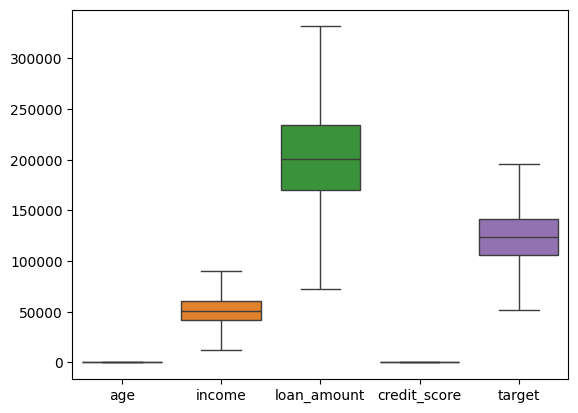

In [17]:
sns.boxplot(df)
plt.show()

In [18]:
df['city'].value_counts()


city
Hyderabad    260
Chennai      259
Bangalore    256
Mumbai       225
Name: count, dtype: int64

In [19]:
df["employment_type"].value_counts()

employment_type
Self-Employed    356
Salaried         325
Unemployed       319
Name: count, dtype: int64

In [20]:
# Convering ordinal columns into numerical using One Hot Encoding
cat=['city','employment_type']
from sklearn.preprocessing import OneHotEncoder

encoded=OneHotEncoder(sparse_output=False)
encoded_data=encoded.fit_transform(df[cat])
encoded_data


array([[0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.]], shape=(1000, 7))

In [21]:
encoded_df=pd.DataFrame(encoded_data,columns=encoded.get_feature_names_out(cat))
encoded_df

,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,1.0,0.0,0.0
996,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [22]:
df=pd.concat([df.drop(columns=cat),encoded_df],axis=1)


In [23]:
df

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,40301.406736,129081.713353,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,51119.925190,272663.033166,502.604714,155285.942941,0.0,1.0,0.0,0.0,1.0,0.0,0.0
996,64,36687.617333,133069.710014,730.751324,65076.404995,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,62,43438.125495,234645.931152,747.044458,126006.462108,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,35,60835.720367,169706.958962,628.847359,118101.789665,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [24]:
# find the skewness of input features
skewness = df.drop(columns=['target']).skew()
skewness

age                             -0.042322
income                           0.187505
loan_amount                      0.134521
credit_score                    -0.044087
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
dtype: float64

In [29]:
# the normal ,postive skewed and negative skewed features
normal_features = skewness[skewness.abs() < 0.5].index.tolist()
positive_skewed_features = skewness[skewness > 0.5].index.tolist()
negative_skewed_features = skewness[skewness < -0.5].index.tolist()
print("Normal features:", normal_features)
print("Positively skewed features:", positive_skewed_features)
print("Negatively skewed features:", negative_skewed_features)

Normal features: ['age', 'income', 'loan_amount', 'credit_score']
Positively skewed features: ['city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negatively skewed features: []


--> For normal skew we use MinMaxscaler scaling<br>
--> For left and right skew we use Standard Scaler Scaling. z score=x-mean/std i.e;mean=0,std=1.Here in Standard scaler we convert the left and right skew into normal distribution using standardization technique i.e; z-score.

In [27]:
from sklearn.preprocessing import MinMaxScaler

normal_skew=['income','loan_amount']
scale=MinMaxScaler()
df[normal_skew]=scale.fit_transform(df[normal_skew])


In [28]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [32]:
from sklearn.preprocessing import StandardScaler

scale=StandardScaler()
df[['credit_score']]=scale.fit_transform(df[['credit_score']])


In [35]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,2.013602,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,-0.763656,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,-0.545133,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,0.873248,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,-0.381642,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [36]:
x=df.drop(columns='target',axis=1)
y=df['target']

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 23859.720391321927


In [44]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 892109719.7222213


In [45]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -0.10162123010347357
